## Cell 1: Import thư viện và cấu hình hệ thống

In [1]:
import os
import struct
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

APPRECIATE_PATH = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_appreciate_1M/Behance_appreciate_1M.txt'
OWNERS_PATH     = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_Item_to_Owners/Behance_Item_to_Owners.txt'
FEAT_PATH       = '/kaggle/input/datasets/oanhkimnguyen/behance-image-features/Behance_Image_Features.b'

SAVE_DIR = '/kaggle/working/processed/'
os.makedirs(SAVE_DIR, exist_ok=True)

K_CORE              = 10
CANDIDATE_POOL_SIZE = 500
PCA_DIM             = 512

TRAIN_RATIO         = 0.70
VAL_RATIO           = 0.15
TEST_RATIO          = 0.15

SEQ_LEN             = 10
REWARD_EXACT_MATCH  = 1.0

TRANSFORMER_LAYERS = 2
TRANSFORMER_HEADS  = 4
EMBED_DIM_ID       = 256
HIDDEN_SIZE        = 512

MAX_EPISODES       = 5000
ENTROPY_START      = 0.05
ENTROPY_END        = 0.01
SEED               = 42

print(f"K-Core Filter      : >= {K_CORE} tương tác")
print(f"Candidate Pool     : {CANDIDATE_POOL_SIZE} items")
print(f"PCA Image Features : {PCA_DIM} dimensions")
print(f"Sequence Length (L): {SEQ_LEN} items/state")
print(f"Output Directory   : {SAVE_DIR}")


K-Core Filter      : >= 10 tương tác
Candidate Pool     : 500 items
PCA Image Features : 512 dimensions
Sequence Length (L): 10 items/state
Output Directory   : /kaggle/working/processed/


## Cell 1.1: Cố định seed

In [2]:
import random
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"Đã cố định Seed: {SEED}")

Đã cố định Seed: 42


## Cell 2: Load Dữ liệu và Thống kê Cơ bản

In [3]:
df_inter = pd.read_csv(
    APPRECIATE_PATH,
    sep=r'\s+',
    header=None,
    names=['user_id', 'item_id', 'timestamp']
)
print(f"Đã load xong {len(df_inter):,} lượt tương tác.")

print("\nĐang load dữ liệu Owners (Item -> User)...")
df_owners = pd.read_csv(
    OWNERS_PATH,
    sep=r'\s+',
    header=None,
    names=['item_id', 'owner_id']
)
print(f"Đã load xong {len(df_owners):,} record owners.")

def load_image_features(filepath):
    features = {}
    print(f"\nĐang load Image Features (~2.8GB) từ {filepath} ...")
    
    with open(filepath, 'rb') as f:
        count = 0
        while True:
            raw_id = f.read(8)
            if len(raw_id) < 8:
                break
            
            item_id = raw_id.decode('ascii').strip('\x00')
            
            raw_feat = f.read(4096 * 4)
            if len(raw_feat) < 4096 * 4:
                break
                
            feat = struct.unpack('4096f', raw_feat)
            features[item_id] = np.array(feat, dtype=np.float32)
            
            count += 1
            if count % 50000 == 0:
                print(f"   ... Đã load được {count:,} items")
                
    return features

features = load_image_features(FEAT_PATH)
print(f"Đã load thành công đặc trưng của {len(features):,} bức ảnh.")

n_users_raw = df_inter['user_id'].nunique()
n_items_raw = df_inter['item_id'].nunique()
n_inter_raw = len(df_inter)
density_raw = n_inter_raw / (n_users_raw * n_items_raw)

print(f"- Số lượng Users        : {n_users_raw:,}")
print(f"- Số lượng Items        : {n_items_raw:,}")
print(f"- Tổng lượt tương tác   : {n_inter_raw:,}")
print(f"- Mức độ thưa thớt (Sparsity): {(1 - density_raw)*100:.6f}%")
print(f"- Mật độ (Density)      : {density_raw*100:.6f}%")


display(df_inter.head())

Đã load xong 1,000,000 lượt tương tác.

Đang load dữ liệu Owners (Item -> User)...
Đã load xong 186,560 record owners.

Đang load Image Features (~2.8GB) từ /kaggle/input/datasets/oanhkimnguyen/behance-image-features/Behance_Image_Features.b ...
   ... Đã load được 50,000 items
   ... Đã load được 100,000 items
   ... Đã load được 150,000 items
Đã load thành công đặc trưng của 178,787 bức ảnh.
- Số lượng Users        : 63,497
- Số lượng Items        : 178,788
- Tổng lượt tương tác   : 1,000,000
- Mức độ thưa thớt (Sparsity): 99.991191%
- Mật độ (Density)      : 0.008809%


,user_id,item_id,timestamp
0,276633,1588231,1307583271
1,1238354,1529213,1307583273
2,165550,485000,1307583337
3,2173258,776972,1307583340
4,165550,158226,1307583406


## Cell 2.1. EDA TEMPORAL ANALYSIS

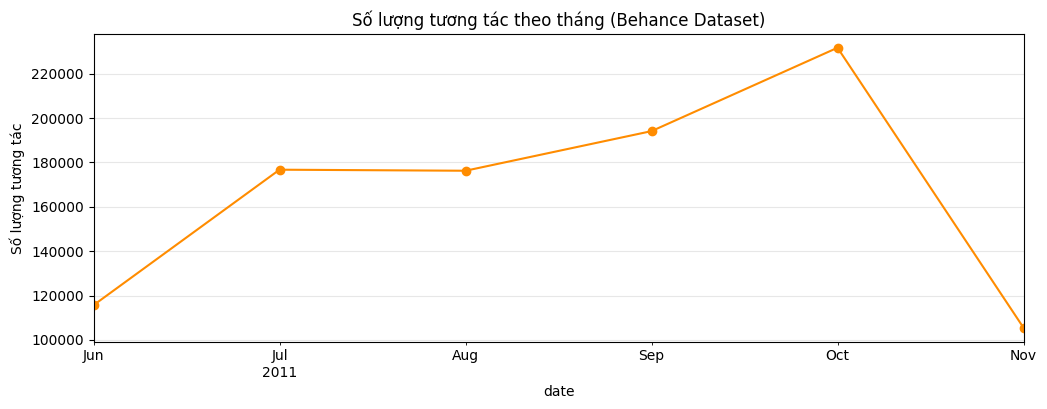

In [4]:
df_inter['date'] = pd.to_datetime(df_inter['timestamp'], unit='s')
monthly_counts = df_inter.set_index('date').resample('M').size()

plt.figure(figsize=(12, 4))
monthly_counts.plot(color='darkorange', marker='o')
plt.title("Số lượng tương tác theo tháng (Behance Dataset)")
plt.ylabel("Số lượng tương tác")
plt.grid(alpha=0.3)
plt.show()

## Cell 3: Thống kê tổng quan và Độ thưa thớt

In [5]:
n_users = df_inter['user_id'].nunique()
n_items = df_inter['item_id'].nunique()
n_interactions = len(df_inter)
sparsity = 1 - (n_interactions / (n_users * n_items))

print(f"- Số lượng Users: {n_users:,}")
print(f"- Số lượng Items: {n_items:,}")
print(f"- Tổng tương tác: {n_interactions:,}")
print(f"- Sparsity (Độ thưa): {sparsity*100:.6f}%")

- Số lượng Users: 63,497
- Số lượng Items: 178,788
- Tổng tương tác: 1,000,000
- Sparsity (Độ thưa): 99.991191%


## Cell 4: Phân tích độ bao phủ (coverage) và action space

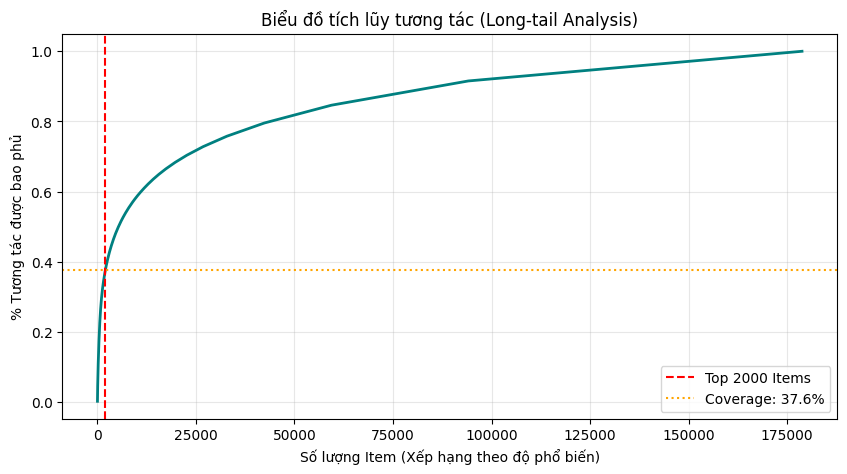

In [6]:
item_counts = df_inter.groupby('item_id').size().sort_values(ascending=False)
cumulative_sum = np.cumsum(item_counts.values) / n_interactions

plt.figure(figsize=(10, 5))
plt.plot(range(len(item_counts)), cumulative_sum, color='teal', lw=2)
plt.axvline(2000, color='red', linestyle='--', label='Top 2000 Items')
plt.axhline(cumulative_sum[2000], color='orange', linestyle=':', label=f'Coverage: {cumulative_sum[2000]*100:.1f}%')
plt.title("Biểu đồ tích lũy tương tác (Long-tail Analysis)")
plt.xlabel("Số lượng Item (Xếp hạng theo độ phổ biến)")
plt.ylabel("% Tương tác được bao phủ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Cell 5: Chiều dài chuỗi hành vi

PHÂN TÍCH CHUỖI:
- Chiều dài trung bình: 15.7
- Median: 4.0
- Tỷ lệ user có >= 10 tương tác: 29.2%


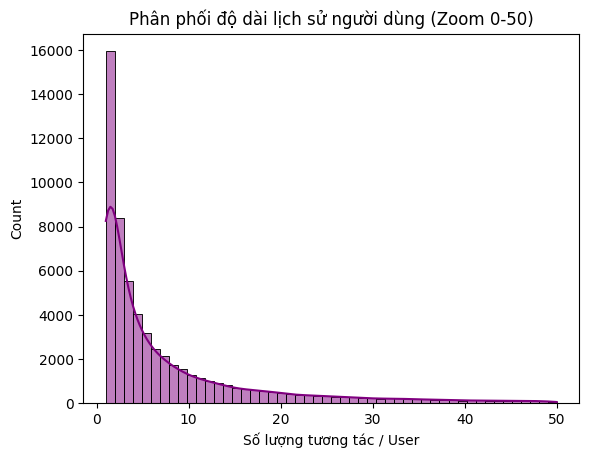

In [7]:
user_hist_len = df_inter.groupby('user_id').size()

print(f"PHÂN TÍCH CHUỖI:")
print(f"- Chiều dài trung bình: {user_hist_len.mean():.1f}")
print(f"- Median: {user_hist_len.median()}")
print(f"- Tỷ lệ user có >= 10 tương tác: {(user_hist_len >= 10).mean()*100:.1f}%")

sns.histplot(user_hist_len[user_hist_len <= 50], bins=50, kde=True, color='purple')
plt.title("Phân phối độ dài lịch sử người dùng (Zoom 0-50)")
plt.xlabel("Số lượng tương tác / User")
plt.show()

## Cell 6: Phân tích Phân phối (Long-tail) và Áp dụng Bộ lọc K-Core (>= 10)

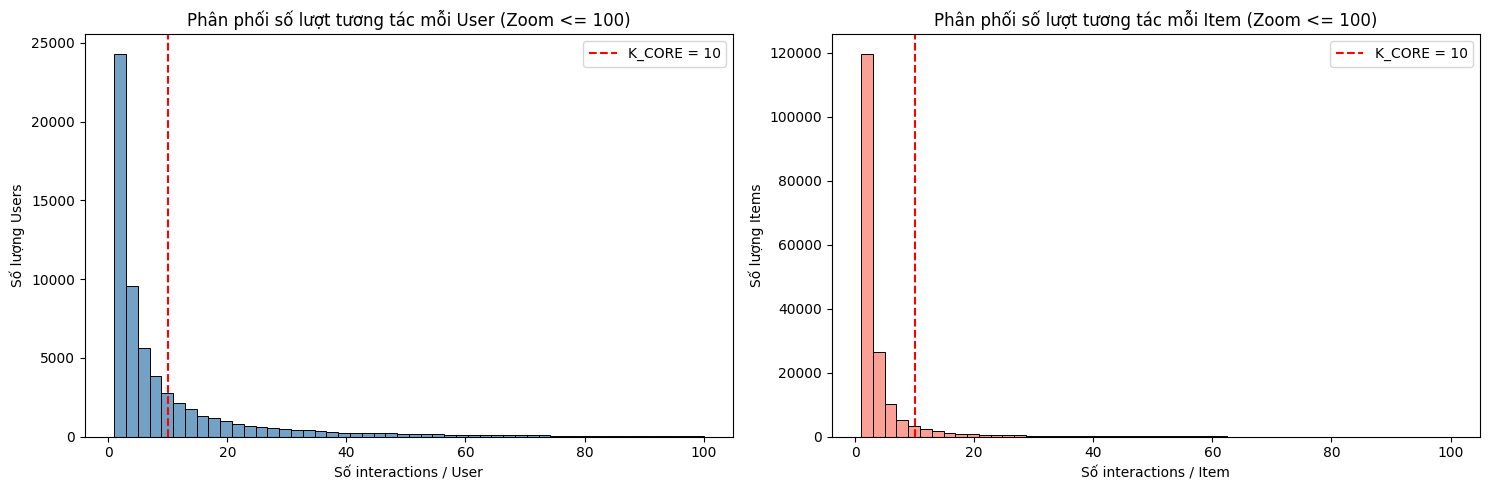

Đang áp dụng 10-core filter...
[Vòng 1] Lọc còn: 562,188 interactions
[Vòng 2] Lọc còn: 519,142 interactions
[Vòng 3] Lọc còn: 509,010 interactions
[Vòng 4] Lọc còn: 507,010 interactions
[Vòng 5] Lọc còn: 506,534 interactions
[Vòng 6] Lọc còn: 506,453 interactions
[Vòng 7] Lọc còn: 506,435 interactions
[Vòng 8] Lọc còn: 506,435 interactions
Filter hội tụ ở vòng 8!
BÁO CÁO SAU KHI LỌC 10-CORE
- Users giữ lại      : 12,772 / 63,497 (20.1%)
- Items giữ lại      : 12,535 / 178,788 (7.0%)
- Tương tác giữ lại  : 506,435 / 1,000,000 (50.6%)
- Mật độ mới (Density): 0.3163%


In [8]:
user_counts_raw = df_inter.groupby('user_id').size()
item_counts_raw = df_inter.groupby('item_id').size()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(user_counts_raw[user_counts_raw <= 100], bins=50, color='steelblue', ax=axes[0])
axes[0].set_title('Phân phối số lượt tương tác mỗi User (Zoom <= 100)')
axes[0].set_xlabel('Số interactions / User')
axes[0].set_ylabel('Số lượng Users')
axes[0].axvline(K_CORE, color='red', linestyle='--', label=f'K_CORE = {K_CORE}')
axes[0].legend()

sns.histplot(item_counts_raw[item_counts_raw <= 100], bins=50, color='salmon', ax=axes[1])
axes[1].set_title('Phân phối số lượt tương tác mỗi Item (Zoom <= 100)')
axes[1].set_xlabel('Số interactions / Item')
axes[1].set_ylabel('Số lượng Items')
axes[1].axvline(K_CORE, color='red', linestyle='--', label=f'K_CORE = {K_CORE}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Đang áp dụng {K_CORE}-core filter...")

def apply_kcore(df, k=10, max_iter=20):
    for i in range(max_iter):
        before_len = len(df)
        
        # Đếm số lượng
        user_cnt = df.groupby('user_id').size()
        item_cnt = df.groupby('item_id').size()
        
        # Giữ lại những ID thỏa mãn >= k
        valid_users = user_cnt[user_cnt >= k].index
        valid_items = item_cnt[item_cnt >= k].index
        
        # Filter
        df = df[df['user_id'].isin(valid_users) & df['item_id'].isin(valid_items)]
        
        print(f"[Vòng {i+1}] Lọc còn: {len(df):,} interactions")
        
        if len(df) == before_len:
            print(f"Filter hội tụ ở vòng {i+1}!")
            break
            
    return df.reset_index(drop=True)

df_filtered = apply_kcore(df_inter, k=K_CORE)

n_users_f = df_filtered['user_id'].nunique()
n_items_f = df_filtered['item_id'].nunique()
n_inter_f = len(df_filtered)
density_f = n_inter_f / (n_users_f * n_items_f)

print(f"BÁO CÁO SAU KHI LỌC {K_CORE}-CORE")

print(f"- Users giữ lại      : {n_users_f:,} / {n_users_raw:,} ({n_users_f/n_users_raw*100:.1f}%)")
print(f"- Items giữ lại      : {n_items_f:,} / {n_items_raw:,} ({n_items_f/n_items_raw*100:.1f}%)")
print(f"- Tương tác giữ lại  : {n_inter_f:,} / {n_inter_raw:,} ({n_inter_f/n_inter_raw*100:.1f}%)")
print(f"- Mật độ mới (Density): {density_f*100:.4f}%")


## Cell 7: Xây dựng Candidate Pool và Chuẩn hóa ID

Đã loại bỏ các items không có ảnh. Còn lại 12,535 items hợp lệ.
BÁO CÁO CANDIDATE POOL (ACTION SPACE = 500)
- Số lượng Candidate Items : 500
- Lượt tương tác được phủ  : 164,234 / 506,435
- Tỷ lệ Coverage (Độ phủ)  : 32.43%


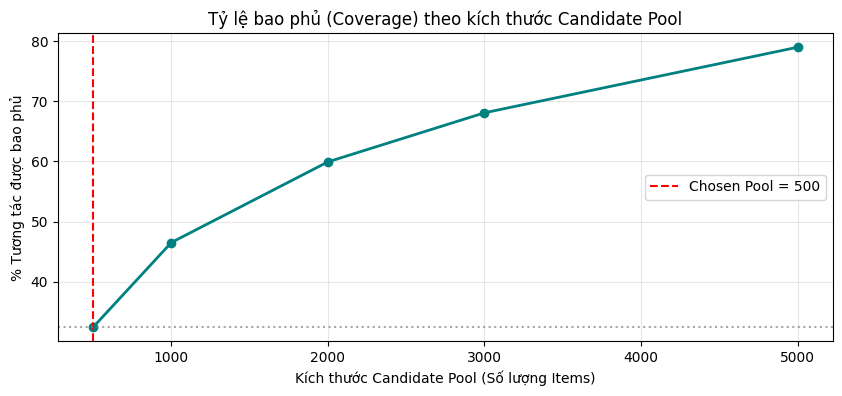


Đang chuyển đổi ID thành Index liên tục (0, 1, 2...)...
Đã lưu file Mappings thành công vào: /kaggle/working/processed/
- Tổng số Users Index : 0 -> 12771
- Tổng số Items Index : 0 -> 12534


In [9]:
df_filtered['item_id_str'] = df_filtered['item_id'].astype(str).str.zfill(8)

items_with_features = set(features.keys())
df_filtered = df_filtered[df_filtered['item_id_str'].isin(items_with_features)].copy()

print(f"Đã loại bỏ các items không có ảnh. Còn lại {df_filtered['item_id'].nunique():,} items hợp lệ.")

item_popularity = df_filtered.groupby('item_id').size().sort_values(ascending=False)

candidate_pool_raw = item_popularity.head(CANDIDATE_POOL_SIZE).index.tolist()
candidate_set_raw = set(candidate_pool_raw)

coverage_interactions = df_filtered[df_filtered['item_id'].isin(candidate_set_raw)].shape[0]
coverage_percent = (coverage_interactions / len(df_filtered)) * 100

print(f"BÁO CÁO CANDIDATE POOL (ACTION SPACE = {CANDIDATE_POOL_SIZE})")

print(f"- Số lượng Candidate Items : {len(candidate_pool_raw):,}")
print(f"- Lượt tương tác được phủ  : {coverage_interactions:,} / {len(df_filtered):,}")
print(f"- Tỷ lệ Coverage (Độ phủ)  : {coverage_percent:.2f}%")


pool_sizes =[500, 1000, 2000, 3000, 5000]
coverages = [(df_filtered[df_filtered['item_id'].isin(item_popularity.head(k).index)].shape[0] / len(df_filtered)) * 100 for k in pool_sizes]

plt.figure(figsize=(10, 4))
plt.plot(pool_sizes, coverages, marker='o', color='teal', linewidth=2)
plt.axvline(CANDIDATE_POOL_SIZE, color='red', linestyle='--', label=f'Chosen Pool = {CANDIDATE_POOL_SIZE}')
plt.axhline(coverage_percent, color='gray', linestyle=':', alpha=0.7)
plt.title(f'Tỷ lệ bao phủ (Coverage) theo kích thước Candidate Pool')
plt.xlabel('Kích thước Candidate Pool (Số lượng Items)')
plt.ylabel('% Tương tác được bao phủ')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nĐang chuyển đổi ID thành Index liên tục (0, 1, 2...)...")

unique_users = sorted(df_filtered['user_id'].unique())
unique_items = sorted(df_filtered['item_id'].unique())

user2idx = {u: i for i, u in enumerate(unique_users)}
item2idx = {it: i for i, it in enumerate(unique_items)}

# Lưu index ngược để sau này Demo (Index -> ID gốc -> Link ảnh Behance)
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

# Áp dụng mapping vào dataframe
df_filtered['user_idx'] = df_filtered['user_id'].map(user2idx)
df_filtered['item_idx'] = df_filtered['item_id'].map(item2idx)

# Chuyển candidate pool sang dạng index
candidate_pool_idx = [item2idx[it] for it in candidate_pool_raw]

# Lưu Mappings ra ổ đĩa để dùng cho Giai đoạn 6 (Xây dựng Web App Demo)
import json
with open(os.path.join(SAVE_DIR, 'user_mappings.json'), 'w') as f:
    json.dump({str(k): int(v) for k, v in user2idx.items()}, f)
    
with open(os.path.join(SAVE_DIR, 'item_mappings.json'), 'w') as f:
    json.dump({str(k): int(v) for k, v in item2idx.items()}, f)

print(f"Đã lưu file Mappings thành công vào: {SAVE_DIR}")
print(f"- Tổng số Users Index : 0 -> {len(user2idx)-1}")
print(f"- Tổng số Items Index : 0 -> {len(item2idx)-1}")

## Cell 8: Độ tương đồng thẩm mỹ trong chuỗi

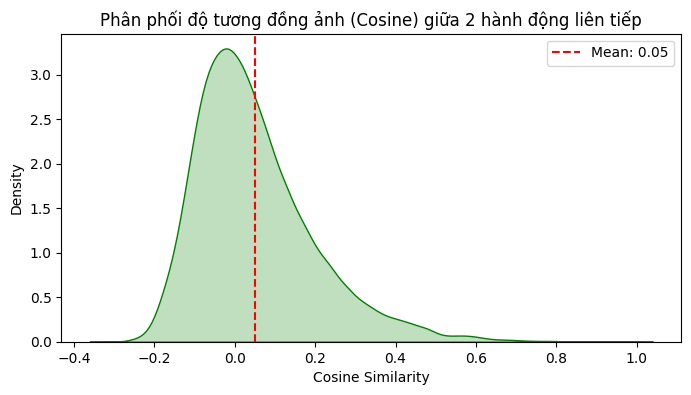

In [10]:
df_filtered = df_filtered.sort_values(['user_idx', 'timestamp'])
train_traj = df_filtered.groupby('user_idx')['item_idx'].apply(list).to_dict()

n_items_total = len(item2idx)
image_features_matrix = np.zeros((n_items_total, 4096), dtype=np.float32)
for it_raw, idx in item2idx.items():
    image_features_matrix[idx] = features[str(it_raw).zfill(8)]

pca = PCA(n_components=512, random_state=42)
image_features_512 = pca.fit_transform(image_features_matrix) 

sample_similarities = []
sample_users = np.random.choice(list(train_traj.keys()), 1000)

for u in sample_users:
    traj = train_traj[u]
    if len(traj) < 2: continue
    for i in range(len(traj)-1):
        idx1, idx2 = traj[i], traj[i+1]
        
        v1, v2 = image_features_512[idx1], image_features_512[idx2]
        
        # Tính Cosine
        sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
        sample_similarities.append(sim)

plt.figure(figsize=(8, 4))
sns.kdeplot(sample_similarities, fill=True, color='green')
plt.axvline(np.mean(sample_similarities), color='red', linestyle='--', label=f'Mean: {np.mean(sample_similarities):.2f}')
plt.title("Phân phối độ tương đồng ảnh (Cosine) giữa 2 hành động liên tiếp")
plt.xlabel("Cosine Similarity")
plt.legend()
plt.show()

## Cell 9: Phân tích độ khó (REWARD SPARSITY)

In [11]:
random_hit_rate = 1 / 2000
pop_hit_rate = 0.0039 

print(f"PHÂN TÍCH ĐỘ KHÓ:")
print(f"- Xác suất trúng ngẫu nhiên: {random_hit_rate*100:.4f}%")
print(f"- Xác suất trúng của Popularity: {pop_hit_rate*100:.4f}%")

PHÂN TÍCH ĐỘ KHÓ:
- Xác suất trúng ngẫu nhiên: 0.0500%
- Xác suất trúng của Popularity: 0.3900%


## Cell 10: Chia tập dữ liệu Train/Val/Test, Xây dựng Trajectories và Chạy PCA.

Đã chia xong:
   - Train : 359,994 interactions (71.1%)
   - Val   : 76,966 interactions (15.2%)
   - Test  : 69,475 interactions (13.7%)
Đã lưu các file Trajectories và Candidate Pool vào: /kaggle/working/processed/


Chuẩn bị Ma trận:   0%|          | 0/12535 [00:00<?, ?it/s]

PCA hoàn tất! Giữ lại được 76.72% lượng thông tin (Variance).


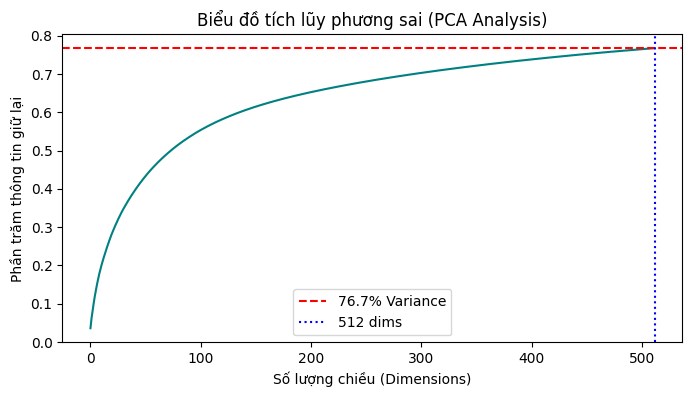

In [12]:
df_filtered = df_filtered.sort_values(['user_idx', 'timestamp']).reset_index(drop=True)

# Tính toán tỷ lệ vị trí của từng tương tác trong chuỗi lịch sử của mỗi User
df_filtered['rank'] = df_filtered.groupby('user_idx').cumcount()
df_filtered['total'] = df_filtered.groupby('user_idx')['user_idx'].transform('count')
df_filtered['pct'] = df_filtered['rank'] / df_filtered['total']

# Chia tập (70% Train - 15% Val - 15% Test)
df_train = df_filtered[df_filtered['pct'] < TRAIN_RATIO]
df_val   = df_filtered[(df_filtered['pct'] >= TRAIN_RATIO) & (df_filtered['pct'] < TRAIN_RATIO + VAL_RATIO)]
df_test  = df_filtered[df_filtered['pct'] >= TRAIN_RATIO + VAL_RATIO]

print(f"Đã chia xong:")
print(f"   - Train : {len(df_train):,} interactions ({len(df_train)/len(df_filtered)*100:.1f}%)")
print(f"   - Val   : {len(df_val):,} interactions ({len(df_val)/len(df_filtered)*100:.1f}%)")
print(f"   - Test  : {len(df_test):,} interactions ({len(df_test)/len(df_filtered)*100:.1f}%)")

def extract_trajectories(df):
    return df.groupby('user_idx')['item_idx'].apply(list).to_dict()

train_traj = extract_trajectories(df_train)
val_traj   = extract_trajectories(df_val)
test_traj  = extract_trajectories(df_test)

with open(os.path.join(SAVE_DIR, 'train_trajectories.pkl'), 'wb') as f: pickle.dump(train_traj, f)
with open(os.path.join(SAVE_DIR, 'val_trajectories.pkl'), 'wb') as f:   pickle.dump(val_traj, f)
with open(os.path.join(SAVE_DIR, 'test_trajectories.pkl'), 'wb') as f:  pickle.dump(test_traj, f)

with open(os.path.join(SAVE_DIR, 'candidate_pool.pkl'), 'wb') as f: pickle.dump(candidate_pool_idx, f)

print(f"Đã lưu các file Trajectories và Candidate Pool vào: {SAVE_DIR}")

n_items_total = len(item2idx)
feature_matrix = np.zeros((n_items_total, 4096), dtype=np.float32)

for it_raw, idx in tqdm(item2idx.items(), desc="Chuẩn bị Ma trận"):
    feature_matrix[idx] = features[str(it_raw).zfill(8)]

train_item_idxs = df_train['item_idx'].unique()

scaler = StandardScaler()
# Fit trên Train, Transform trên Toàn bộ
scaler.fit(feature_matrix[train_item_idxs])
feature_matrix_scaled = scaler.transform(feature_matrix)

pca = PCA(n_components=PCA_DIM, random_state=42)
# Fit trên Train, Transform trên Toàn bộ
pca.fit(feature_matrix_scaled[train_item_idxs])
feature_matrix_pca = pca.transform(feature_matrix_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA hoàn tất! Giữ lại được {explained_var*100:.2f}% lượng thông tin (Variance).")

np.save(os.path.join(SAVE_DIR, 'image_features_512.npy'), feature_matrix_pca)

# EDA: PCA VARIANCE RATIO
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='teal')
plt.axhline(y=explained_var, color='red', linestyle='--', label=f'{explained_var*100:.1f}% Variance')
plt.axvline(x=PCA_DIM, color='blue', linestyle=':', label=f'{PCA_DIM} dims')
plt.title("Biểu đồ tích lũy phương sai (PCA Analysis)")
plt.xlabel("Số lượng chiều (Dimensions)")
plt.ylabel("Phần trăm thông tin giữ lại")
plt.legend()
plt.show()

## Cell 11: Xây dựng môi trường học tăng cường

In [13]:
import time

item_popularity_train = df_train.groupby('item_id').size()
class BehanceEnvV3:
    def __init__(self, trajectories, candidate_pool_idx, image_features, item_popularity, seq_len=10):
        self.trajectories   = trajectories
        self.candidate_pool = np.array(candidate_pool_idx, dtype=np.int32)
        self.seq_len        = seq_len

        norms = np.linalg.norm(image_features, axis=1, keepdims=True)
        norms[norms == 0] = 1e-10
        self.norm_features = image_features / norms

        raw_pops = item_popularity.reindex(candidate_pool_idx).fillna(0).values
        self.pop_scores  = raw_pops / (raw_pops.max() + 1e-10)
        self.item_to_pop = dict(zip(candidate_pool_idx, self.pop_scores))

        self.n_items_total = len(image_features)
        self.pad_token     = self.n_items_total
        self.valid_users   = [u for u, traj in trajectories.items() if len(traj) >= 2]

    def reset(self, user_idx=None):
        if user_idx is None:
            user_idx = random.choice(self.valid_users)
        self.current_user = user_idx
        self.current_traj = self.trajectories[user_idx]
        self.t = 1
        return self._get_state()

    def _get_state(self):
        history = self.current_traj[max(0, self.t - self.seq_len): self.t]
        pad_len = self.seq_len - len(history)
        return np.array([self.pad_token] * pad_len + history, dtype=np.int32)

    def step(self, action_item_idx):
        target_item = self.current_traj[self.t]
        reward = 0.0

        if action_item_idx == target_item:
            reward += 15.0                       
        else:
            cos_sim = np.dot(self.norm_features[action_item_idx],
                             self.norm_features[target_item])
            reward += max(0.0, cos_sim) * 6.0

        pop = self.item_to_pop.get(action_item_idx, 0.0)
        reward += (1.0 - pop) * 0.5

        if self.t >= 2:
            prev_item = self.current_traj[self.t - 1]
            div_sim = np.dot(self.norm_features[action_item_idx],
                             self.norm_features[prev_item])
            reward += max(0.0, 1.0 - div_sim) * 0.3

        recent = self.current_traj[max(0, self.t - 5): self.t]
        if action_item_idx in recent:
            pos = list(reversed(recent)).index(action_item_idx)
            reward -= 3.0 * (1.0 + pos / 5.0)

        self.t += 1
        done = (self.t >= len(self.current_traj))
        next_state = self._get_state() if not done else np.array([self.pad_token] * self.seq_len)
        reward = np.clip(reward, -10, 15)
        return next_state, reward, done, {"target": target_item}

## Cell 12: Kiến trúc mạng neural cho RL

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị tính toán: {device}")

class TransformerEncoderV2(nn.Module):
    def __init__(self, feature_matrix, hidden_size=512, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        pad_vec   = np.zeros((1, feature_matrix.shape[1]), dtype=np.float32)
        full_feat = np.vstack([feature_matrix, pad_vec])

        self.img_embed = nn.Embedding.from_pretrained(torch.tensor(full_feat), freeze=True)
        self.id_embed  = nn.Embedding(len(full_feat), 256)
        nn.init.normal_(self.id_embed.weight, std=0.01)

        self.project   = nn.Linear(feature_matrix.shape[1] + 256, hidden_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, SEQ_LEN, hidden_size))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, nhead=n_heads,
            dim_feedforward=hidden_size * 2,
            dropout=dropout, batch_first=True,
            norm_first=True 
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.out_proj = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.GELU(), nn.Dropout(dropout)
        )
        self.hidden_size = hidden_size

    def forward(self, state_indices):
        img_x    = self.img_embed(state_indices)
        id_x     = self.id_embed(state_indices)
        x        = self.project(torch.cat([img_x, id_x], dim=-1)) + self.pos_embed
        pad_mask = (state_indices == env.pad_token)
        x        = self.transformer(x, src_key_padding_mask=pad_mask)
        return self.out_proj(x[:, -1, :])


class DQN_Network(nn.Module):
    def __init__(self, encoder, action_dim=CANDIDATE_POOL_SIZE):
        super().__init__()
        self.encoder = encoder
        self.fc1 = nn.Linear(encoder.hidden_size, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, action_dim)

    def forward(self, state_indices):
        user_rep = self.encoder(state_indices)
        return self.fc2(self.relu(self.fc1(user_rep)))


class A2CNetworkV2(nn.Module):
    def __init__(self, encoder, action_dim=CANDIDATE_POOL_SIZE):
        super().__init__()
        self.encoder = encoder
        h = encoder.hidden_size
        self.actor  = nn.Sequential(nn.Linear(h, 512), nn.ReLU(), nn.Dropout(0.1), nn.Linear(512, action_dim))
        self.critic = nn.Sequential(nn.Linear(h, 256), nn.ReLU(), nn.Dropout(0.1), nn.Linear(256, 1))
        self.actor_fc1 = self.actor[0];  self.actor_fc2 = self.actor[3]
        self.critic_fc1 = self.critic[0]; self.critic_fc2 = self.critic[3]

    def forward(self, state_indices):
        rep = self.encoder(state_indices)
        return self.actor(rep), self.critic(rep)


dqn_model = DQN_Network(TransformerEncoderV2(image_features_512).to(device)).to(device)
a2c_model = A2CNetworkV2(TransformerEncoderV2(image_features_512).to(device)).to(device)

Đang sử dụng thiết bị tính toán: cuda


## Cell 13: Huấn luyện Baseline DQN

Bắt đầu huấn luyện DQN (5000 Episodes)...


Train DQN:   0%|          | 0/5000 [00:00<?, ?it/s]

DQN | Ep:  100 | Loss: 0.0041 | Reward TB: 26.11
DQN | Ep:  200 | Loss: 0.0203 | Reward TB: 29.15
DQN | Ep:  300 | Loss: 0.0173 | Reward TB: 24.45
DQN | Ep:  400 | Loss: 0.0165 | Reward TB: 25.15
DQN | Ep:  500 | Loss: 0.0170 | Reward TB: 32.08
DQN | Ep:  600 | Loss: 0.0215 | Reward TB: 23.87
DQN | Ep:  700 | Loss: 0.0245 | Reward TB: 26.03
DQN | Ep:  800 | Loss: 0.0245 | Reward TB: 38.23
DQN | Ep:  900 | Loss: 0.0214 | Reward TB: 27.42
DQN | Ep: 1000 | Loss: 0.0290 | Reward TB: 26.00
DQN | Ep: 1100 | Loss: 0.0317 | Reward TB: 28.22
DQN | Ep: 1200 | Loss: 0.0229 | Reward TB: 24.29
DQN | Ep: 1300 | Loss: 0.0215 | Reward TB: 33.86
DQN | Ep: 1400 | Loss: 0.0364 | Reward TB: 27.56
DQN | Ep: 1500 | Loss: 0.0246 | Reward TB: 29.48
DQN | Ep: 1600 | Loss: 0.0296 | Reward TB: 23.96
DQN | Ep: 1700 | Loss: 0.0234 | Reward TB: 30.68
DQN | Ep: 1800 | Loss: 0.0325 | Reward TB: 29.77
DQN | Ep: 1900 | Loss: 0.0238 | Reward TB: 27.72
DQN | Ep: 2000 | Loss: 0.0270 | Reward TB: 31.06
DQN | Ep: 2100 | Los

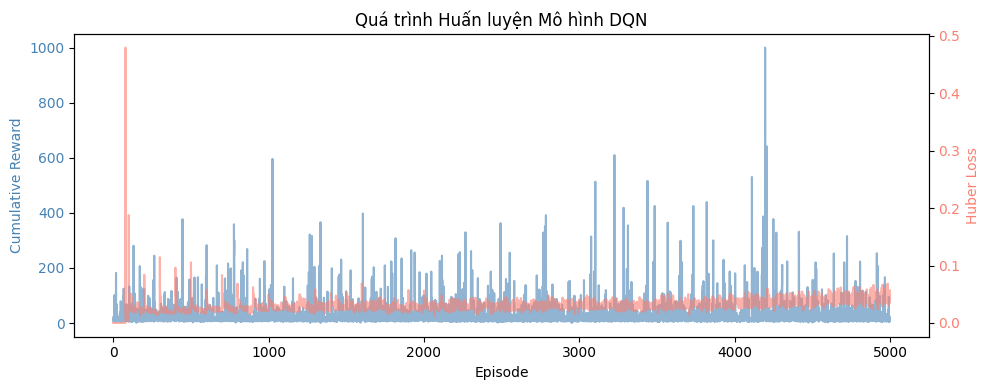

In [15]:
import random
from collections import deque
import torch.optim as optim
import copy

BATCH_SIZE    = 256          
GAMMA         = 0.95
LR            = 3e-4       
BUFFER_SIZE   = 100_000    
MAX_EPISODES  = 5000
TARGET_UPDATE = 100          
WARMUP_STEPS  = 2000       

EPSILON_START = 1.0
EPSILON_END   = 0.05
EPSILON_DECAY = 0.997       

class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta_start=0.4, beta_frames=50000):
        self.capacity    = capacity
        self.alpha       = alpha
        self.beta_start  = beta_start
        self.beta_frames = beta_frames
        self.frame       = 1
        self.buffer      = []
        self.priorities  = np.zeros(capacity, dtype=np.float32)
        self.pos         = 0

    def push(self, state, action_idx, reward, next_state, done):
        max_p = self.priorities.max() if self.buffer else 1.0
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action_idx, reward, next_state, done))
        else:
            self.buffer[self.pos] = (state, action_idx, reward, next_state, done)
        self.priorities[self.pos] = max_p
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        n     = len(self.buffer)
        probs = self.priorities[:n] ** self.alpha
        probs /= probs.sum()
        idxs  = np.random.choice(n, batch_size, replace=False, p=probs)
        beta  = min(1.0, self.beta_start + self.frame * (1.0 - self.beta_start) / self.beta_frames)
        self.frame += 1
        w = (n * probs[idxs]) ** (-beta)
        w /= w.max()
        batch = [self.buffer[i] for i in idxs]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards, dtype=np.float32),
                np.array(next_states), np.array(dones, dtype=np.float32),
                idxs, np.array(w, dtype=np.float32))

    def update_priorities(self, idxs, td_errors):
        for i, e in zip(idxs, td_errors):
            self.priorities[i] = abs(e) + 1e-6

    def __len__(self):
        return len(self.buffer)

dqn_net    = DQN_Network(TransformerEncoderV2(image_features_512), action_dim=CANDIDATE_POOL_SIZE).to(device)
target_net = copy.deepcopy(dqn_net).to(device)

optimizer = optim.AdamW(dqn_net.parameters(), lr=LR, weight_decay=1e-4)  # [IMPROVE] Adam → AdamW
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPISODES, eta_min=1e-5)  # [IMPROVE] thêm scheduler
buffer    = PrioritizedReplayBuffer(BUFFER_SIZE)
epsilon   = EPSILON_START

print(f"Bắt đầu huấn luyện DQN ({MAX_EPISODES} Episodes)...")

best_reward    = -float('inf')
history_rewards = []
history_losses  = []

env = BehanceEnvV3(train_traj, candidate_pool_idx, image_features_512, item_popularity, seq_len=SEQ_LEN)

for episode in tqdm(range(1, MAX_EPISODES + 1), desc="Train DQN"):
    state     = env.reset()
    ep_reward = 0
    ep_loss   = 0
    steps     = 0

    while True:
        if random.random() < epsilon:
            action_idx = random.randrange(CANDIDATE_POOL_SIZE)
        else:
            with torch.no_grad():
                state_tensor = torch.tensor([state], dtype=torch.long).to(device)
                action_idx   = dqn_net(state_tensor).argmax().item()

        real_item_idx              = env.candidate_pool[action_idx]
        next_state, reward, done, _ = env.step(real_item_idx)
        buffer.push(state, action_idx, reward, next_state, done)
        state      = next_state
        ep_reward += reward
        steps     += 1

        if len(buffer) >= max(BATCH_SIZE, WARMUP_STEPS):
            b_states, b_actions, b_rewards, b_next_states, b_dones, idxs, w = buffer.sample(BATCH_SIZE)

            b_states      = torch.tensor(b_states,      dtype=torch.long).to(device)
            b_actions     = torch.tensor(b_actions,     dtype=torch.long).unsqueeze(1).to(device)
            b_rewards     = torch.tensor(b_rewards).unsqueeze(1).to(device)
            b_next_states = torch.tensor(b_next_states, dtype=torch.long).to(device)
            b_dones       = torch.tensor(b_dones).unsqueeze(1).to(device)
            w             = torch.tensor(w).unsqueeze(1).to(device)

            current_q = dqn_net(b_states).gather(1, b_actions)

            with torch.no_grad():
                best_actions = dqn_net(b_next_states).argmax(1, keepdim=True)
                max_next_q   = target_net(b_next_states).gather(1, best_actions)
                target_q     = b_rewards + (GAMMA * max_next_q * (1 - b_dones))

            td_errors = (current_q - target_q).detach().cpu().numpy().flatten()
            buffer.update_priorities(idxs, td_errors)

            loss = (w * F.smooth_l1_loss(current_q, target_q, reduction='none')).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(dqn_net.parameters(), max_norm=1.0)
            optimizer.step()
            ep_loss += loss.item()

        if done:
            break

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    scheduler.step()  # [IMPROVE]

    avg_ep_loss = ep_loss / steps if steps > 0 else 0
    history_rewards.append(ep_reward)
    history_losses.append(avg_ep_loss)

    if episode % 100 == 0:
        avg_reward_100 = np.mean(history_rewards[-100:])
        print(f"DQN | Ep: {episode:4d} | Loss: {ep_loss/max(steps, 1):.4f} | Reward TB: {avg_reward_100:.2f}")

    if ep_reward > best_reward:
        best_reward = ep_reward
        torch.save(dqn_net.state_dict(), os.path.join(SAVE_DIR, 'best_dqn.pth'))

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(dqn_net.state_dict())

print(f"ĐÃ HOÀN TẤT HUẤN LUYỆN DQN!")
print(f"Best Reward đạt được: {best_reward:.2f}")
print(f"Trọng số đã lưu tại: {os.path.join(SAVE_DIR, 'best_dqn.pth')}")

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(history_rewards, color='steelblue', alpha=0.6, label='Reward')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Cumulative Reward', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(history_losses, color='salmon', alpha=0.6, label='Loss')
ax2.set_ylabel('Huber Loss', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')

plt.title('Quá trình Huấn luyện Mô hình DQN')
fig.tight_layout()
plt.show()

## Cell 14: Huấn luyện có giám sát (WARM-UP ACTOR)

In [16]:
a2c_encoder = TransformerEncoderV2(image_features_512).to(device)
a2c_net = A2CNetworkV2(a2c_encoder, action_dim=CANDIDATE_POOL_SIZE).to(device)

warmup_optimizer = optim.Adam(a2c_net.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

# Trích xuất một tập nhỏ mẫu (State, Target) từ Train Trajectories
warmup_data = []
for u, traj in list(train_traj.items())[:5000]: # Lấy 5000 users đầu
    for i in range(1, len(traj)):
        state = traj[max(0, i-SEQ_LEN):i]
        pad_len = SEQ_LEN - len(state)
        state_padded = [env.pad_token]*pad_len + state
        # Tìm index của target_item trong Candidate Pool
        target_item = traj[i]
        if target_item in env.candidate_pool:
            target_idx = np.where(env.candidate_pool == target_item)[0][0]
            warmup_data.append((state_padded, target_idx))

# Huấn luyện trong 5 Epochs
for epoch in range(10):
    random.shuffle(warmup_data)
    total_loss = 0
    # Batch size thủ công cho Warm-up
    for i in range(0, len(warmup_data), 128):
        batch = warmup_data[i:i+128]
        states = torch.tensor([b[0] for b in batch], dtype=torch.long).to(device)
        targets = torch.tensor([b[1] for b in batch], dtype=torch.long).to(device)
        
        logits, _ = a2c_net(states)
        loss = criterion(logits, targets)
        
        warmup_optimizer.zero_grad()
        loss.backward()
        warmup_optimizer.step()
        total_loss += loss.item()
    print(f"Warm-up Epoch {epoch+1}/5 | Loss: {total_loss/len(warmup_data):.4f}")

Warm-up Epoch 1/5 | Loss: 0.0478
Warm-up Epoch 2/5 | Loss: 0.0460
Warm-up Epoch 3/5 | Loss: 0.0430
Warm-up Epoch 4/5 | Loss: 0.0399
Warm-up Epoch 5/5 | Loss: 0.0381
Warm-up Epoch 6/5 | Loss: 0.0367
Warm-up Epoch 7/5 | Loss: 0.0355
Warm-up Epoch 8/5 | Loss: 0.0344
Warm-up Epoch 9/5 | Loss: 0.0334
Warm-up Epoch 10/5 | Loss: 0.0324


## Cell 15: Huấn luyện Mô hình chính A2C

Huấn luyện A2C với Transformer (5000 Episodes)...


Train A2C:   0%|          | 0/5000 [00:00<?, ?it/s]

A2C | Ep:  100 | Reward TB: 36.47 | Beta: 0.049 | Entropy: 0.71
A2C | Ep:  200 | Reward TB: 25.00 | Beta: 0.048 | Entropy: 2.85
A2C | Ep:  300 | Reward TB: 25.24 | Beta: 0.048 | Entropy: 1.77
A2C | Ep:  400 | Reward TB: 29.85 | Beta: 0.047 | Entropy: 2.50
A2C | Ep:  500 | Reward TB: 35.44 | Beta: 0.046 | Entropy: 2.61
A2C | Ep:  600 | Reward TB: 34.57 | Beta: 0.045 | Entropy: 1.04
A2C | Ep:  700 | Reward TB: 40.21 | Beta: 0.044 | Entropy: 1.38
A2C | Ep:  800 | Reward TB: 21.75 | Beta: 0.044 | Entropy: 3.60
A2C | Ep:  900 | Reward TB: 30.19 | Beta: 0.043 | Entropy: 2.83
A2C | Ep: 1000 | Reward TB: 21.55 | Beta: 0.042 | Entropy: 4.56
A2C | Ep: 1100 | Reward TB: 31.44 | Beta: 0.041 | Entropy: 4.68
A2C | Ep: 1200 | Reward TB: 26.39 | Beta: 0.040 | Entropy: 2.66
A2C | Ep: 1300 | Reward TB: 19.69 | Beta: 0.040 | Entropy: 4.89
A2C | Ep: 1400 | Reward TB: 31.50 | Beta: 0.039 | Entropy: 4.63
A2C | Ep: 1500 | Reward TB: 38.51 | Beta: 0.038 | Entropy: 4.78
A2C | Ep: 1600 | Reward TB: 35.20 | Beta

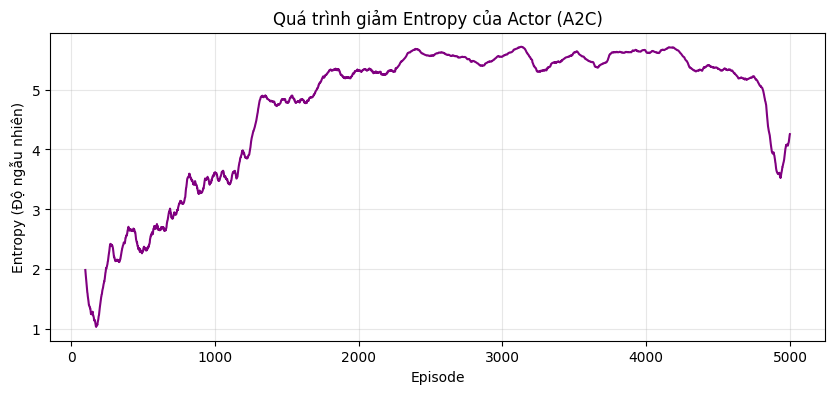

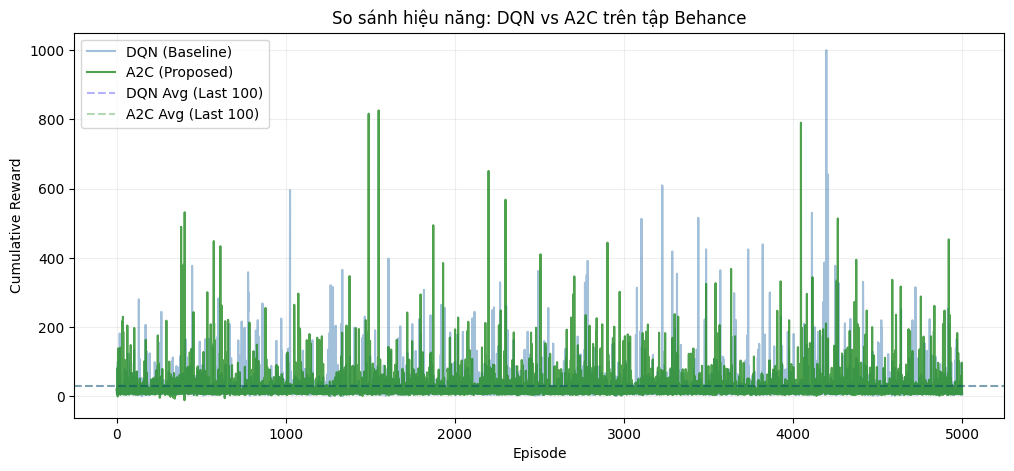

In [17]:
import torch.optim as optim
from torch.distributions import Categorical

N_STEPS         = 8        
LR_ACTOR        = 5e-5
LR_CRITIC       = 1e-4
GAMMA           = 0.95
MAX_EP_A2C      = 5000

optimizer_a2c = optim.Adam([
    {'params': a2c_net.actor_fc1.parameters(), 'lr': LR_ACTOR},
    {'params': a2c_net.actor_fc2.parameters(), 'lr': LR_ACTOR},
    {'params': a2c_net.critic_fc1.parameters(), 'lr': LR_CRITIC},
    {'params': a2c_net.critic_fc2.parameters(), 'lr': LR_CRITIC},
    {'params': a2c_net.encoder.transformer.parameters(), 'lr': LR_ACTOR},
    {'params': a2c_net.encoder.id_embed.parameters(), 'lr': LR_ACTOR},
    {'params': a2c_net.encoder.project.parameters(), 'lr': LR_ACTOR}
])

best_reward_a2c = -float('inf')
history_rewards_a2c = []
history_entropy_a2c = []
print(f"Huấn luyện A2C với Transformer ({MAX_EP_A2C} Episodes)...")

for episode in tqdm(range(1, MAX_EP_A2C + 1), desc="Train A2C"):
    entropy_beta = max(ENTROPY_END, ENTROPY_START - (episode / MAX_EP_A2C) * (ENTROPY_START - ENTROPY_END))
    
    state = env.reset()
    done = False
    ep_reward = 0
    
    while not done:
        log_probs, values, rewards, entropies = [], [], [], []
        
        for _ in range(N_STEPS):
            state_tensor = torch.tensor([state], dtype=torch.long).to(device)
            logits, value = a2c_net(state_tensor)
            
            T = 1.0  # tăng từ 0.5 → 1.0
            probs = F.softmax(logits / T, dim=-1)
            dist = Categorical(probs)
            action_idx = dist.sample()
            
            log_probs.append(dist.log_prob(action_idx))
            values.append(value)
            entropies.append(dist.entropy())
            
            real_item_idx = env.candidate_pool[action_idx.item()]
            next_state, reward, done, _ = env.step(real_item_idx)
            
            rewards.append(reward)
            ep_reward += reward
            state = next_state
            if done: break
            
        # Tính Loss
        if done:
            R = 0
        else:
            with torch.no_grad():
                _, next_value = a2c_net(torch.tensor([state], dtype=torch.long).to(device))
                R = next_value.item()
                
        returns = []
        for r in reversed(rewards):
            R = r + GAMMA * R
            returns.insert(0, R)
            
        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        values = torch.cat(values).squeeze()
        log_probs = torch.cat(log_probs)
        entropies = torch.cat(entropies)
        
        advantages = returns - values.detach()
        if len(advantages) > 1:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        actor_loss = -(log_probs * advantages).mean() - entropy_beta * entropies.mean()
        critic_loss = F.mse_loss(values, returns)
        total_loss = actor_loss + 0.5 * critic_loss
        
        optimizer_a2c.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(a2c_net.parameters(), max_norm=0.5)
        optimizer_a2c.step()
        
    history_rewards_a2c.append(ep_reward)
    
    if episode % 100 == 0:
        avg_reward = np.mean(history_rewards_a2c[-100:])
        print(f"A2C | Ep: {episode:4d} | Reward TB: {avg_reward:.2f} | Beta: {entropy_beta:.3f} | Entropy: {entropies.mean().item():.2f}")
        
    if ep_reward > best_reward_a2c:
        best_reward_a2c = ep_reward
        torch.save(a2c_net.state_dict(), os.path.join(SAVE_DIR, 'best_a2c.pth'))
    
    history_entropy_a2c.append(entropies.mean().item())

print(f"ĐÃ HOÀN TẤT HUẤN LUYỆN A2C!")
print(f"Best Reward A2C: {best_reward_a2c:.2f} (So với DQN: {best_reward:.2f})")
print(f"Trọng số đã lưu tại: {os.path.join(SAVE_DIR, 'best_a2c.pth')}")

# BIỂU ĐỒ ENTROPY CỦA A2C
plt.figure(figsize=(10, 4))
plt.plot(pd.Series(history_entropy_a2c).rolling(100).mean(), color='purple')
plt.title("Quá trình giảm Entropy của Actor (A2C)")
plt.xlabel("Episode")
plt.ylabel("Entropy (Độ ngẫu nhiên)")
plt.grid(alpha=0.3)
plt.show()

# Vẽ biểu đồ so sánh DQN vs A2C
plt.figure(figsize=(12, 5))
plt.plot(history_rewards, label='DQN (Baseline)', color='steelblue', alpha=0.5)
plt.plot(history_rewards_a2c, label='A2C (Proposed)', color='forestgreen', alpha=0.8)
plt.axhline(y=np.mean(history_rewards[-100:]), color='blue', linestyle='--', alpha=0.3, label='DQN Avg (Last 100)')
plt.axhline(y=np.mean(history_rewards_a2c[-100:]), color='green', linestyle='--', alpha=0.3, label='A2C Avg (Last 100)')
plt.title('So sánh hiệu năng: DQN vs A2C trên tập Behance')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Cell 16: Định nghĩa Top-K Metrics

In [18]:
def get_ndcg(rank):
    """Tính Discounted Cumulative Gain."""
    return 1 / np.log2(rank + 2)

def evaluate_model(model, model_type, test_trajectories, env, k=10):
    """
    Đánh giá mô hình trên tập Test theo các chỉ số chuẩn của Hệ thống gợi ý.
    """
    hits = []
    ndcgs = []
    recommended_items = set()
    
    # Chuyển model sang chế độ đánh giá
    if hasattr(model, 'eval'): model.eval()
    
    print(f"Đánh giá {model_type} trên {len(test_trajectories):,} users")
    
    for user_idx, traj in tqdm(test_trajectories.items()):
        if len(traj) < 2: continue
        
        history = traj[:-1]
        target = traj[-1]
        
        # Lấy state theo đúng format của Env (có padding)
        state = history[-env.seq_len:]
        pad_len = env.seq_len - len(state)
        if pad_len > 0:
            state = [env.pad_token] * pad_len + state
        
        state_tensor = torch.tensor([state], dtype=torch.long).to(device)
        
        with torch.no_grad():
            if model_type == "DQN":
                scores = model(state_tensor).squeeze().cpu().numpy()
            elif model_type == "A2C":
                logits, _ = model(state_tensor)
                scores = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
            elif model_type == "Popularity":
                # Trả về điểm phổ biến đã tính ở Cell 4
                scores = item_popularity.reindex(env.candidate_pool).fillna(0).values
            else: # Random
                scores = np.random.rand(len(env.candidate_pool))

        history_set = set(history)
        for i, item_idx in enumerate(env.candidate_pool):
            if item_idx in history_set:
                scores[i] = -999999 # Gán điểm cực thấp để không bao giờ được gợi ý lại

        # Lấy Top-K
        top_k_indices = np.argsort(scores)[-k:][::-1]
        top_k_items = [env.candidate_pool[idx] for idx in top_k_indices]
        
        # Cập nhật Coverage
        recommended_items.update(top_k_items)
        
        # Kiểm tra Hit và NDCG
        if target in top_k_items:
            hits.append(1)
            rank = top_k_items.index(target)
            ndcgs.append(get_ndcg(rank))
        else:
            hits.append(0)
            ndcgs.append(0)
            
    hr = np.mean(hits)
    ndcg = np.mean(ndcgs)
    cov = (len(recommended_items) / len(env.candidate_pool)) * 100
    
    return hr, ndcg, cov

## Cell 17: CHẠY ĐÁNH GIÁ SO SÁNH

Đánh giá Random trên 12,772 users


  0%|          | 0/12772 [00:00<?, ?it/s]

Đánh giá Popularity trên 12,772 users


  0%|          | 0/12772 [00:00<?, ?it/s]

Đánh giá DQN trên 12,772 users


  0%|          | 0/12772 [00:00<?, ?it/s]

Đánh giá A2C trên 12,772 users


  0%|          | 0/12772 [00:00<?, ?it/s]


BẢNG KẾT QUẢ TRUNG TÂM:


,Model,HR@10,NDCG@10,Coverage
0,Random,0.005969,0.002409,100.000000
1,Popularity,0.005760,0.002550,2.800000
2,DQN (Baseline),0.007854,0.003455,99.600000
3,A2C (Proposed),0.010891,0.004738,28.800000


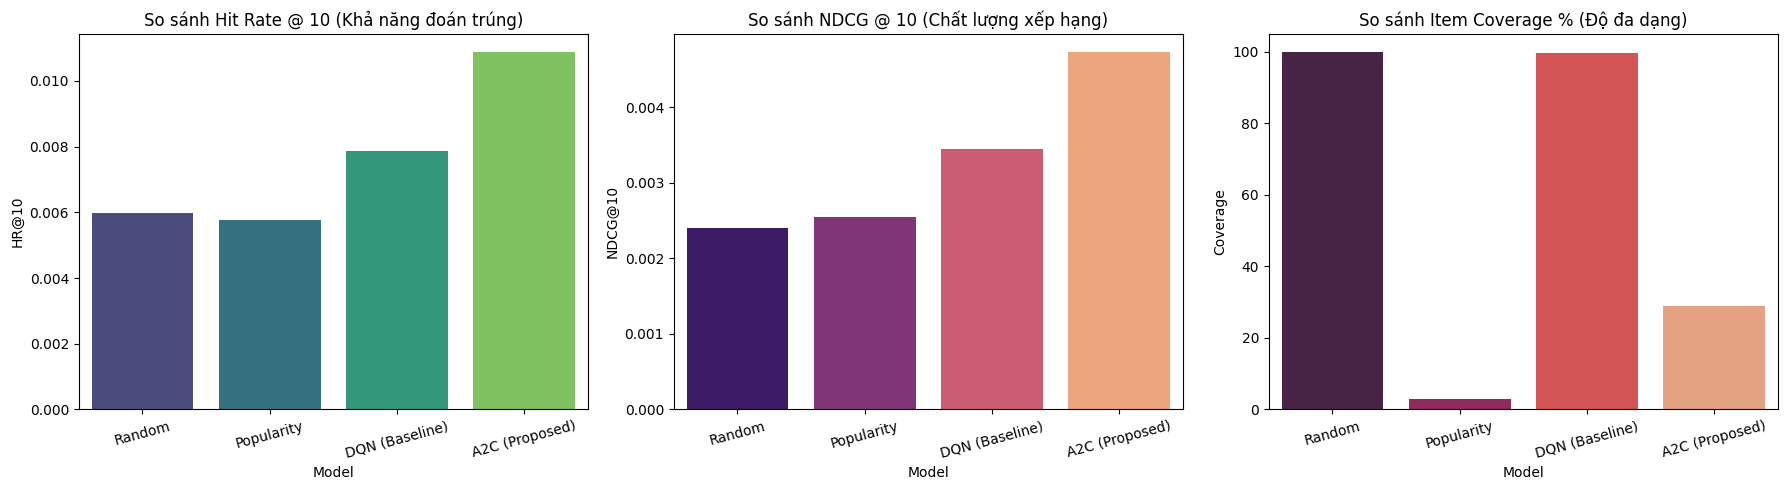

In [19]:
# 1. Load trọng số tốt nhất đã lưu
dqn_model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_dqn.pth')))
a2c_model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_a2c.pth')))

# 2. Đánh giá từng mô hình
results = []

# Đánh giá Random
hr, ndcg, cov = evaluate_model(None, "Random", test_traj, env)
results.append({"Model": "Random", "HR@10": hr, "NDCG@10": ndcg, "Coverage": cov})

# Đánh giá Popularity
hr, ndcg, cov = evaluate_model(None, "Popularity", test_traj, env)
results.append({"Model": "Popularity", "HR@10": hr, "NDCG@10": ndcg, "Coverage": cov})

# Đánh giá DQN
hr, ndcg, cov = evaluate_model(dqn_model, "DQN", test_traj, env)
results.append({"Model": "DQN (Baseline)", "HR@10": hr, "NDCG@10": ndcg, "Coverage": cov})

# Đánh giá A2C
hr, ndcg, cov = evaluate_model(a2c_model, "A2C", test_traj, env)
results.append({"Model": "A2C (Proposed)", "HR@10": hr, "NDCG@10": ndcg, "Coverage": cov})

# 3. Hiển thị Bảng kết quả (Leaderboard)
df_results = pd.DataFrame(results)
print("\nBẢNG KẾT QUẢ TRUNG TÂM:")
display(df_results.style.highlight_max(subset=['HR@10', 'NDCG@10', 'Coverage'], color='lightgreen'))

# Vẽ biểu đồ so sánh các chỉ số
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_results, x='Model', y='HR@10', ax=axes[0], palette='viridis')
axes[0].set_title('So sánh Hit Rate @ 10 (Khả năng đoán trúng)')

sns.barplot(data=df_results, x='Model', y='NDCG@10', ax=axes[1], palette='magma')
axes[1].set_title('So sánh NDCG @ 10 (Chất lượng xếp hạng)')

sns.barplot(data=df_results, x='Model', y='Coverage', ax=axes[2], palette='rocket')
axes[2].set_title('So sánh Item Coverage % (Độ đa dạng)')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Cell 18: ĐÓNG GÓI DỮ LIỆU CHO DEMO APP (FLASK/FASTAPI)

In [20]:
import shutil

np.save(os.path.join(SAVE_DIR, 'candidate_pool.npy'), np.array(candidate_pool_idx))

with open(os.path.join(SAVE_DIR, 'idx2item.json'), 'w') as f:
    json.dump({int(k): str(v) for k, v in idx2item.items()}, f)

# Lưu item_popularity
item_pop_dict = item_popularity.to_dict()
with open(os.path.join(SAVE_DIR, 'item_popularity.json'), 'w') as f:
    json.dump({str(k): int(v) for k, v in item_pop_dict.items()}, f)

demo_test_traj = {k: test_traj[k] for k in list(test_traj.keys())[:200]}
with open(os.path.join(SAVE_DIR, 'demo_test_trajectories.pkl'), 'wb') as f:
    pickle.dump(demo_test_traj, f)

files_to_download = [
    'user_mappings.json', 
    'item_mappings.json',
    'idx2item.json',
    'image_features_512.npy',
    'candidate_pool.npy',
    'demo_test_trajectories.pkl',
    'best_dqn.pth',
    'best_a2c.pth',
    'item_popularity.json'
]

print("\nDanh sách file tải xuống:")
for file in files_to_download:
    path = os.path.join(SAVE_DIR, file)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"  - {file: <25} | {size_mb: >6.2f} MB")

# Tạo file nén
shutil.make_archive('/kaggle/working/behance_recsys_demo_data', 'zip', SAVE_DIR)


Danh sách file tải xuống:
  - user_mappings.json        |   0.21 MB
  - item_mappings.json        |   0.20 MB
  - idx2item.json             |   0.22 MB
  - image_features_512.npy    |  24.48 MB
  - candidate_pool.npy        |   0.00 MB
  - demo_test_trajectories.pkl |   0.00 MB
  - best_dqn.pth              |  57.29 MB
  - best_a2c.pth              |  57.79 MB
  - item_popularity.json      |   0.18 MB


'/kaggle/working/behance_recsys_demo_data.zip'